In [ ]:
import torch
import torch.nn as nn
import lightning as L
import numpy as np
import segmentation_models_pytorch as smp
from lightning.pytorch.loggers import WandbLogger
import wandb
import matplotlib.pyplot as plt
from lightning.pytorch.callbacks import ModelCheckpoint
from new_data.data_loader import train_loader, val_loader, train_df, val_df
from PIL import Image
from torchvision import transforms
import io
import torchmetrics

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PIL mode: L
shape: (224, 224)
dtype: uint8
min: 0 max: 2
unique values: [0 1 2]


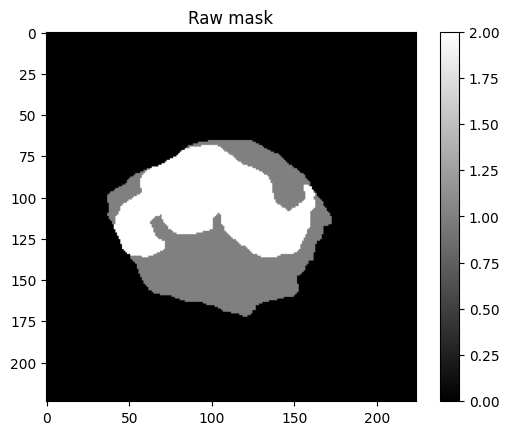

In [4]:
row = train_df.iloc[0]

mask_pil = Image.open(io.BytesIO(row["mask"]))
print("PIL mode:", mask_pil.mode)

mask_np = np.array(mask_pil)
print("shape:", mask_np.shape)
print("dtype:", mask_np.dtype)
print("min:", mask_np.min(), "max:", mask_np.max())
print("unique values:", np.unique(mask_np)[:20])  

plt.imshow(mask_np, cmap="gray")
plt.title("Raw mask")
plt.colorbar()
plt.show()

In [5]:
batch = next(iter(train_loader)) 
images, seg_masks, cls_labels = batch

print(images.shape)
print(seg_masks.shape)
print(cls_labels.shape)
print(seg_masks.dtype)
print(torch.unique(seg_masks))

torch.Size([8, 3, 224, 224])
torch.Size([8, 224, 224])
torch.Size([8])
torch.int64
tensor([0, 1, 2])


In [ ]:
class LitSegClsModel(L.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters() #saves the learning rate as a hyperparameter, which can be accessed later via self.hparams.lr

        aux_params = {
            "pooling": "avg",
            "dropout": 0.5, 
            "activation": None, #Crossentropy works with logits
            "classes": 2,
        }

        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=3,
            aux_params=aux_params
        )

        cls_weights = torch.tensor([1.397, 0.779], dtype=torch.float) #nel training set sono 39 0 e 70 1, allora : totale/2x count_i, i pesi sempre calcolati su training 
        self.register_buffer("cls_weights", cls_weights) #it makes the tensor compatible with GPU

        self.seg_criterion = nn.CrossEntropyLoss()
        self.cls_criterion = nn.CrossEntropyLoss(weight=self.cls_weights)

        self.train_cls_f1 = torchmetrics.classification.BinaryF1Score() 
        self.val_cls_f1 = torchmetrics.classification.BinaryF1Score()

        self.train_cls_precision = torchmetrics.classification.BinaryPrecision()
        self.val_cls_precision = torchmetrics.classification.BinaryPrecision()

        self.train_cls_recall = torchmetrics.classification.BinaryRecall()
        self.val_cls_recall = torchmetrics.classification.BinaryRecall()

        self.train_seg_dice = torchmetrics.classification.MulticlassF1Score(num_classes=3, average="macro")
        self.val_seg_dice = torchmetrics.classification.MulticlassF1Score(num_classes=3, average="macro")

        self.train_seg_iou = torchmetrics.classification.MulticlassJaccardIndex(num_classes=3, average="macro")
        self.val_seg_iou = torchmetrics.classification.MulticlassJaccardIndex(num_classes=3, average="macro")

        self.train_cls_auc = torchmetrics.AUROC(task="binary")
        self.val_cls_auc = torchmetrics.AUROC(task="binary")

    def forward(self, x): #the forward method defines how the model processes input data and produces output
        seg_logits, cls_logits = self.model(x)
        return seg_logits, cls_logits

    def training_step(self, batch, batch_idx):
        images, seg_masks, cls_labels = batch #batch is a tuple containing the input images, the corresponding segmentation masks, and the classification labels. 

        seg_logits, cls_logits = self(images) #self(images) is equivalent to self.forward(images), it calls the forward method of the model to get the segmentation and classification logits.

        seg_loss = self.seg_criterion(seg_logits, seg_masks)
        cls_loss = self.cls_criterion(cls_logits, cls_labels)

        cls_preds=torch.argmax(cls_logits,dim=1) #argmax prende l'indice del valore più grande
        cls_acc=(cls_preds==cls_labels).float().mean()

        seg_preds = torch.argmax(seg_logits, dim=1)

        train_seg_iou = self.train_seg_iou(seg_preds, seg_masks)

        cls_probs = torch.softmax(cls_logits, dim=1)[:,1] #these are probabilities since AUC requires continue values
        train_cls_auc = self.train_cls_auc(cls_probs, cls_labels) #tutte le metriche di torchmetrics hanno questa struttura: metric(preds, target)
        

        loss = seg_loss + cls_loss

        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True) #on_step=True → registra ogni batch, on_epoch=True → registra anche la media sull’epoca
        self.log("train_seg_loss", seg_loss,  on_step=True, on_epoch=True)
        self.log("train_cls_loss", cls_loss,  on_step=True, on_epoch=True)
        self.log("train_cls_acc", cls_acc, prog_bar=True, on_step=True, on_epoch=True )

        self.log("train_seg_dice", self.train_seg_dice(seg_preds, seg_masks), prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_cls_f1", self.train_cls_f1(cls_preds, cls_labels), prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_cls_precision", self.train_cls_precision(cls_preds, cls_labels), on_step=False, on_epoch=True)
        self.log("train_cls_recall", self.train_cls_recall(cls_preds, cls_labels), on_step=False, on_epoch=True)

        self.log("train_seg_iou", train_seg_iou, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_cls_auc", train_cls_auc, prog_bar=True, on_step=False, on_epoch=True)

        return loss

    def validation_step(self, batch, batch_idx):
        images, seg_masks, cls_labels = batch

        seg_logits, cls_logits = self(images) #seg_logits and cls_logits are the raw output of the model, they represent the unnormalized scores for each class in the segmentation and classification tasks, respectively.

        seg_loss = self.seg_criterion(seg_logits, seg_masks)
        cls_loss = self.cls_criterion(cls_logits, cls_labels)

        cls_probs = torch.softmax(cls_logits, dim=1)[:,1]

        seg_preds = torch.argmax(seg_logits, dim=1)
        val_seg_iou = self.val_seg_iou(seg_preds, seg_masks)
        

        loss = seg_loss + cls_loss

        cls_preds = torch.argmax(cls_logits, dim=1)
        cls_acc = (cls_preds == cls_labels).float().mean()

        
        self.val_cls_auc.update(cls_probs, cls_labels)
        self.val_cls_f1.update(cls_preds, cls_labels)
        self.val_cls_precision.update(cls_preds, cls_labels)
        self.val_cls_recall.update(cls_preds, cls_labels)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_seg_loss", seg_loss, on_step=False, on_epoch=True)
        self.log("val_cls_loss", cls_loss, on_step=False, on_epoch=True)
        self.log("val_cls_acc", cls_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_seg_dice", self.val_seg_dice(seg_preds, seg_masks), prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_seg_iou", val_seg_iou, prog_bar=True, on_step=False, on_epoch=True)
        

    

        if batch_idx == 0: #only for the first batch of the validation set
            pred_masks = torch.argmax(seg_logits, dim=1)

            num_images = min(3, images.shape[0])
            val_examples = []

            mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(3, 1, 1)

            class_labels_mask = {
            0: "background",
            1: "class_1",
            2: "class_2",
        }


            for i in range(num_images):
                # denormalize image for visualization
                image_vis = images[i].detach().cpu() * std.cpu() + mean.cpu()
                image_vis = image_vis.clamp(0, 1)  # keep values in [0, 1]
                image_np = image_vis.permute(1, 2, 0).numpy()

                true_mask_np = seg_masks[i].detach().cpu().numpy().astype(np.uint8)
                pred_mask_np = pred_masks[i].detach().cpu().numpy().astype(np.uint8)

                val_examples.append(
                    wandb.Image(
                    image_np,
                    masks={
                    "ground_truth": {
                        "mask_data": true_mask_np,
                        "class_labels": class_labels_mask,
                    },
                    "prediction": {
                        "mask_data": pred_mask_np,
                        "class_labels": class_labels_mask,
                    },
                    },
                    caption=f"Sample {i} | true cls={cls_labels[i].item()} | pred cls={cls_preds[i].item()}"
                )
            )

            self.logger.experiment.log({
            "val_examples": val_examples,
            "global_step": self.global_step
    })
        # if batch_idx == 0:
        #     pred_masks = torch.argmax(seg_logits, dim=1)

        #     num_images = min(3, images.shape[0])
        #     val_examples = []

        #     mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(3, 1, 1)
        #     std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(3, 1, 1)

        #     for i in range(num_images):
        #         image_vis = images[i].detach().cpu() * std.cpu() + mean.cpu()
        #         image_vis = image_vis.clamp(0, 1)
        #         image_np = image_vis.permute(1, 2, 0).numpy()

        #         true_mask_np = seg_masks[i].detach().cpu().numpy()
        #         pred_mask_np = pred_masks[i].detach().cpu().numpy()

        #         fig, axes = plt.subplots(1, 3, figsize=(12, 4)) #it creates a grid 

        #         axes[0].imshow(image_np, cmap="gray" if image_np.shape[2] == 1 else None)
        #         axes[0].set_title(f"Image\ntrue cls={cls_labels[i].item()} | pred cls={cls_preds[i].item()}")
        #         axes[0].axis("off")

        #         axes[1].imshow(true_mask_np, cmap="viridis", vmin=0, vmax=2) #viridis to use different colors for different classes and vmin and vmax denotes the maximum and minimum number of classes
        #         axes[1].set_title("Ground truth")
        #         axes[1].axis("off")

        #         axes[2].imshow(pred_mask_np, cmap="viridis", vmin=0, vmax=2)
        #         axes[2].set_title("Prediction")
        #         axes[2].axis("off")

        #         fig.tight_layout() #to avoid overlap
        #         val_examples.append(wandb.Image(fig))
        #         plt.close(fig)

        #     self.logger.experiment.log({
        #         "val_examples": val_examples,
        #         "global_step": self.global_step
        #     })
    def on_validation_epoch_end(self):
        self.log("val_cls_auc", self.val_cls_auc.compute(), prog_bar=True)
        self.log("val_cls_f1", self.val_cls_f1.compute(), prog_bar=True)
        self.log("val_cls_precision", self.val_cls_precision.compute())
        self.log("val_cls_recall", self.val_cls_recall.compute())

        self.val_cls_auc.reset()
        self.val_cls_f1.reset()
        self.val_cls_precision.reset()
        self.val_cls_recall.reset()
        
    def configure_optimizers(self):
        pg = [p for p in self.parameters() if p.requires_grad]

        optimizer = torch.optim.AdamW(
            pg,
            lr=self.hparams.lr,
            weight_decay=1e-4
        )

        return optimizer
    
    
    

In [8]:
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",   
    mode="min",           
    save_top_k=1
)

In [9]:
def train():
    wandb.init()

    lr = wandb.config.lr

    wandb_logger = WandbLogger(
        project="test_segcls_model",
        log_model=False
    )

    model = LitSegClsModel(lr=lr)

    trainer = L.Trainer(
        max_epochs=10,
        log_every_n_steps=1,
        logger=wandb_logger,
        callbacks=[checkpoint_callback]
    )

    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    wandb.finish()

In [10]:
sweep_config = {
    "method": "grid", #here you are only saying to experiment all the 3 lr
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "lr": {"values": [1e-2, 1e-3, 1e-4]}
    }
}

In [11]:
sweep_id = wandb.sweep(sweep_config, project="test_segcls_model") #It creates a true sweep in the W&B account
print(sweep_id)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/saratramontana/.netrc.


Create sweep with ID: gracouw6
Sweep URL: https://wandb.ai/sara-tramontana02-/test_segcls_model/sweeps/gracouw6
gracouw6


In [12]:
wandb.agent(sweep_id, function=train, count=3) #with sweep_id you are telling which sweep to use
#in this case 3 runs since I have 3 lr 

wandb: Agent Starting Run: ua5inr5m with config:
wandb: 	lr: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/saratramontana/.netrc.
wandb: Currently logged in as: sara-tramontana02 (sara-tramontana02-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/lightning/pytorch/loggers/wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model               │ Unet                   │ 24.4 M │ train │     0 │
│ 1  │ seg_criterion       │ CrossEntropyLoss       │      0 │ train │     0 │
│ 2  │ cls_criterion       │ CrossEntropyLoss       │      0 │ train │     0 │
│ 3  │ train_cls_f1        │ BinaryF1Score          │      0 │ train │     0 │
│ 4  │ val_cls_f1          │ BinaryF1Score          │      0 │ train │     0 │
│ 5  │ train_cls_precision │ BinaryPrecision        │      0 │ train │     0 │
│ 6  │ val_cls_precision   │ BinaryPrecision        │      0 │ train │     0 │
│ 7  │ train_cls_recall    │ BinaryRecall           │      0 │ train │     0 │
│ 8  │ val_cls_recall      │ BinaryRecall           │      0 │ train │     0 │
│ 9  │ train_seg_dice      │ MulticlassF1Score      │      0 │ train │     0 │
│ 10 │ val_seg_dice        │ MulticlassF1Score      │      0 │ train │     0 │
│ 11 │ train_seg_iou       │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 12 │ val_seg_iou         │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 13 │ train_cls_auc       │ BinaryAUROC            │      0 │ train │     0 │
│ 14 │ val_cls_auc         │ BinaryAUROC            │      0 │ train │     0 │
└────┴─────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 209                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

wandb: WARNING Config item 'lr' was locked by 'sweep' (ignored update).


...

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in 
false positive score
  warnings.warn(*args, **kwargs)

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in 
true positive score
  warnings.warn(*args, **kwargs)

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇█████
global_step,▁▂▂▃▄▅▅▆▇▇█
train_cls_acc_epoch,▁▄▆▃██▇█▇█
train_cls_acc_step,███▁█████▇████████████▇█████████▇███████
train_cls_auc,▃▅█▁██▄█▆█
train_cls_f1,▁▄▆▂██▇█▆█
train_cls_loss_epoch,█▅▂▅▁▁▂▁▂▁
train_cls_loss_step,▁▂▁▁▆▁█▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▄▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁
train_cls_precision,▅▅▆▁██▆█▄█
train_cls_recall,▁▅▆▃██▇███
+17,...
